In [7]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
    library("readxl")
    library("ggplot2")
    library("gridExtra")
})

source("../houwie_patches.R")

In [8]:
# t1/2 is log(2) / alpha
# stationary variance is sigma.sq / (2 x alpha)

In [9]:
models <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/F00679/", cd = TRUE, strip = "_F00679_CD_250")

In [10]:
OUwie::getModelTable(models, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-78244.22,-228.6161,-82956.447,156566.78,129654.769,0
ARDOUMA,43,-112461.06,-224.3190,-129766.953,225011.14,198099.123,0
ARDOUMV,43,-510516.56,-222.0081,-510280.266,1021122.13,994210.116,0
ARDOUMVA,48,-2398522.25,-231.5829,-11645497.119,4797144.25,4770232.240,0
EROUM,9,-196104.06,-225.8448,-195873.341,392226.26,365314.252,0
EROUMA,14,-300345.82,-1884.1890,-1850545.883,600719.97,573807.953,0
EROUMV,14,-78597.10,-225.8553,-78366.580,157222.52,130310.511,0
EROUMVA,19,-19861.75,-3639.9567,-191084.017,39762.09,12850.079,0
SYMOUM,23,-148446.07,-210.1108,-148230.986,296939.01,270026.993,0


In [11]:
avgparams <- getModelAvgParams_patched(models, type = "AICc")

In [14]:
head(avgparams)

,rates,alpha,sigma.sq,theta,expected_mean,expected_var,tip_state
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Ratibida_pinnata,0.001396594,0.03188131,0.1729462,-0.8745306,-0.8745309,10737037058,AM
Heliopsis_helianthoides,0.001396594,0.03188131,0.1729462,-0.8745306,-0.8745389,5181933016,AM
Liatris_aspera,0.001396594,0.03188131,0.1729462,-0.8745306,-0.8745442,3043808147,AM
Arnica_sororia,0.001396594,0.03188131,0.1729462,-0.8745306,-0.8745384,5585084025,AM
Arnica_fulgens,0.001396594,0.03188131,0.1729462,-0.8745306,-0.8745384,5585084025,AM
Hymenoxys_richardsonii,0.001396594,0.03188131,0.1729462,-0.8745306,-0.8745312,9059579814,AM


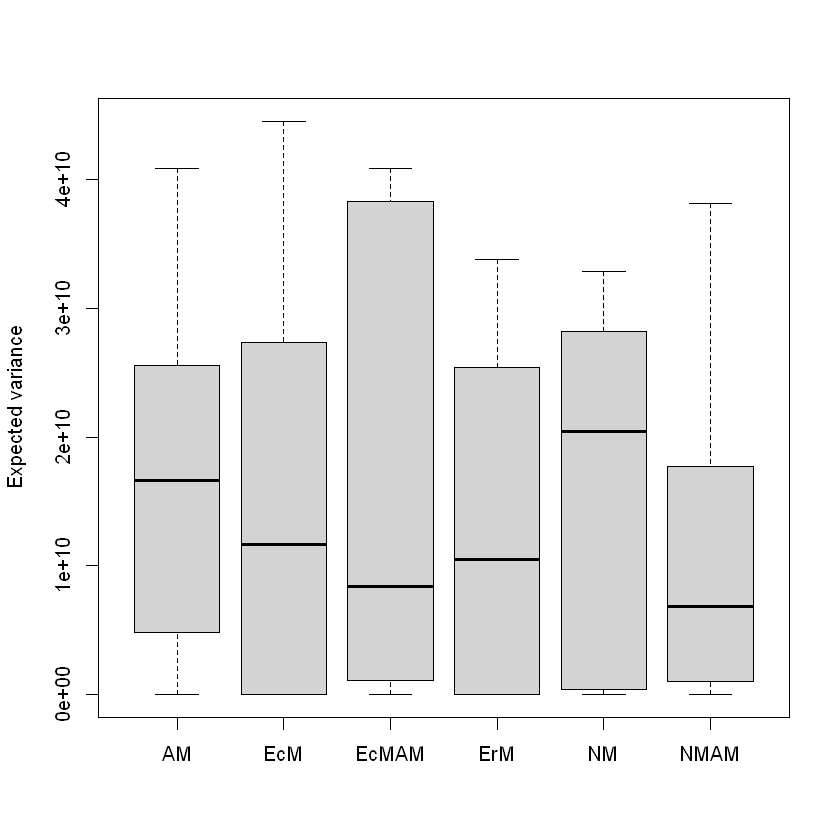

In [16]:
boxplot(expected_var~tip_state, data = avgparams, xlab = NA, ylab = "Expected variance")

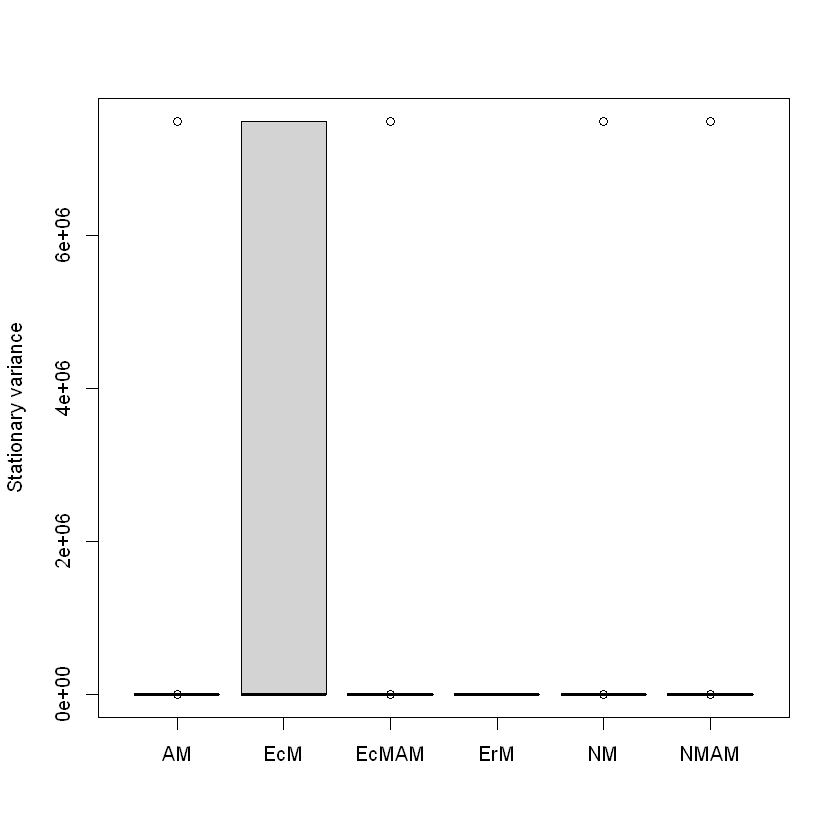

In [27]:
boxplot((sigma.sq/alpha~tip_state), data = avgparams, xlab = NA, ylab = "Stationary variance")

In [35]:
aggregate(avgparams$expected_var, by = list(avgparams$tip_state), FUN = mean)

Group.1,x
<chr>,<dbl>
AM,16413229571
EcM,14639494033
EcMAM,17973602881
ErM,14318265231
NM,15637975948
NMAM,10889597371


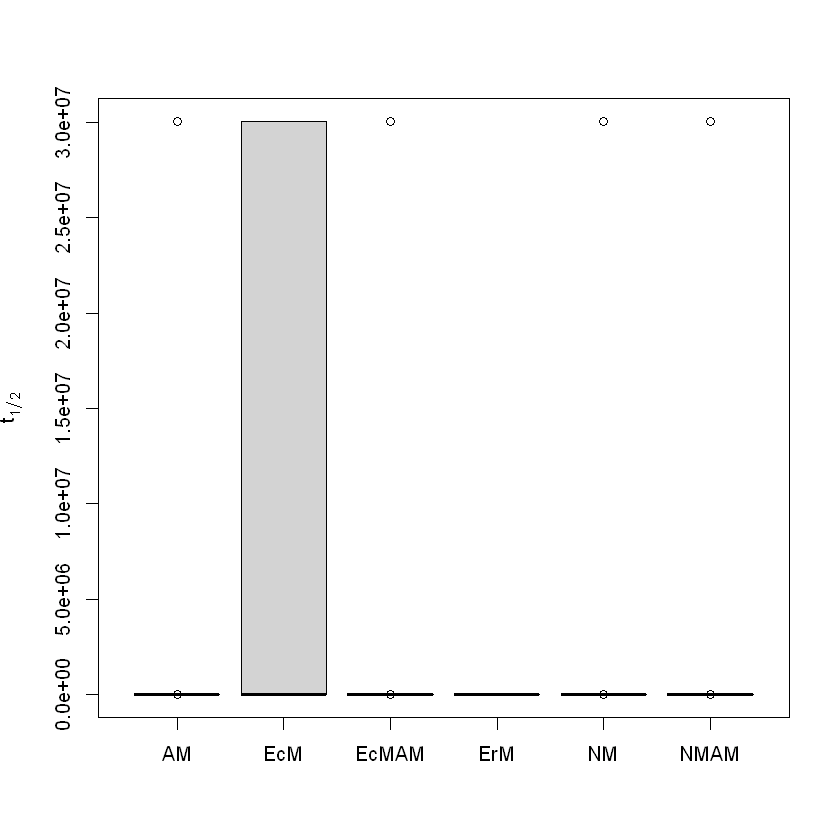

In [29]:
# https://stats.oarc.ucla.edu/r/codefragments/greek_letters/
# use [] for subscripts instead of _{} as in LaTex
# look up the help section of plotmath() function

boxplot(log(2)/alpha~tip_state, data = avgparams, xlab = NA, ylab = expression(t[1/2]))